# 01 — Exploratory Data Analysis

**Credit Card Fraud Detection — ULB / Kaggle**

This notebook is the first step of the project. Before committing to any preprocessing or modeling strategy, we want to understand the data: how imbalanced it is, which features actually carry signal, what the fraud transactions look like compared to normal ones, and whether any obvious transformation is required.

The conclusions of this notebook directly inform the design of `src/data.py` (preprocessing) and the choice of evaluation metrics in the rest of the project.

## 0. Setup

In [26]:
import os
import sys
from pathlib import Path

# Jupyter runs from notebooks/ — move up to the project root so that the
# config-relative paths (data/raw/..., outputs/..., mlruns/...) resolve.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
print('cwd :', Path.cwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import load_config, set_seed

set_seed(0)
cfg = load_config('configs/default.yaml')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

cwd : /Users/sampc/anomaly-detection-fraud


## 1. Loading and overview

We load the raw CSV and check the basics: shape, column types, missing values.

In [27]:
df = pd.read_csv(cfg['paths']['data_raw'])

print('shape   :', df.shape)
print('columns :', list(df.columns))
df.head()

shape   : (284807, 31)
columns : ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [28]:
# dtypes + missing values check
missing = df.isnull().sum()
print('No missing values.' if missing.sum() == 0 else missing[missing > 0])
print()
print(df.dtypes.value_counts())

No missing values.

float64    30
int64       1
Name: count, dtype: int64


In [29]:
# Descriptive stats — focus on the only two non-PCA columns: Time and Amount
df[['Time', 'Amount', 'Class']].describe()

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


Amount ranges from 0 to ~25 691, with a median around 22. The skew is enormous (mean ≈ 88, max ≈ 25 691) — strong indication of a long-tailed distribution. Time spans from 0 to ~172 800 seconds, i.e. exactly 48 hours, so the dataset captures two days of transactions.

## 2. Class distribution — how imbalanced is the data?

Normal : 284,315  (99.827 %)
Fraud  :     492  (0.173 %)
Ratio  : 1 fraud per 577 normal transactions


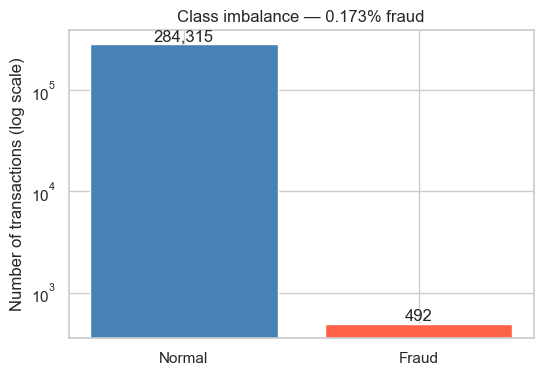

In [30]:
counts = df['Class'].value_counts()
n_total = len(df)
ratio = counts[1] / n_total * 100

print(f'Normal : {counts[0]:>7,}  ({100 - ratio:.3f} %)')
print(f'Fraud  : {counts[1]:>7,}  ({ratio:.3f} %)')
print(f'Ratio  : 1 fraud per {counts[0] // counts[1]} normal transactions')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Normal', 'Fraud'], counts.values, color=['steelblue', 'tomato'])
ax.set_yscale('log')
ax.set_ylabel('Number of transactions (log scale)')
ax.set_title(f'Class imbalance — {ratio:.3f}% fraud')
for i, v in enumerate(counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.show()

**Imbalance is extreme: 0.172% positives.** A trivial classifier predicting always "normal" would score 99.83% accuracy and be useless. This rules out accuracy as an evaluation metric. ROC-AUC is also misleading on imbalanced data because the huge true-negative count inflates the area. **Precision–Recall AUC is the right primary metric** — it focuses on the positive class only.

This also has implications for training: oversampling, class weighting, or unsupervised approaches (training only on the majority class) become natural strategies.

## 3. Distributions of `Amount` and `Time`

These are the two columns that were *not* PCA-transformed by the dataset authors, so they carry the most interpretable signal.

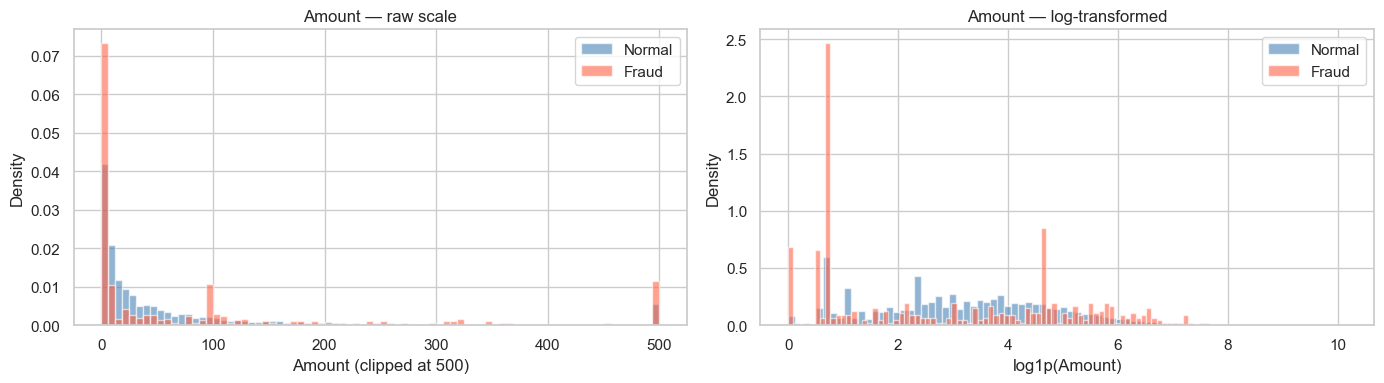

Median Amount  — normal : 22.00
Median Amount  — fraud  : 9.25


In [31]:
normal = df[df['Class'] == 0]
fraud  = df[df['Class'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw Amount — clip to 500 otherwise outliers crush the histogram
axes[0].hist(normal['Amount'].clip(upper=500), bins=80, alpha=0.6,
             label='Normal', density=True, color='steelblue')
axes[0].hist(fraud['Amount'].clip(upper=500), bins=80, alpha=0.6,
             label='Fraud',  density=True, color='tomato')
axes[0].set_xlabel('Amount (clipped at 500)')
axes[0].set_ylabel('Density')
axes[0].set_title('Amount — raw scale')
axes[0].legend()

# log1p(Amount)
axes[1].hist(np.log1p(normal['Amount']), bins=80, alpha=0.6,
             label='Normal', density=True, color='steelblue')
axes[1].hist(np.log1p(fraud['Amount']),  bins=80, alpha=0.6,
             label='Fraud',  density=True, color='tomato')
axes[1].set_xlabel('log1p(Amount)')
axes[1].set_ylabel('Density')
axes[1].set_title('Amount — log-transformed')
axes[1].legend()

fig.tight_layout()
plt.show()

print(f'Median Amount  — normal : {normal["Amount"].median():.2f}')
print(f'Median Amount  — fraud  : {fraud["Amount"].median():.2f}')

On the raw scale the two distributions are visually indistinguishable because of the long tail. After a `log1p` transform, the picture is much clearer: fraud transactions concentrate at lower amounts, with a median below the normal median. The log transform also makes `Amount` look approximately Gaussian — far more tractable for any model that assumes scaled inputs (neural networks, OCSVM with RBF kernel, etc.).

**→ Decision: log-transform `Amount` in preprocessing.**

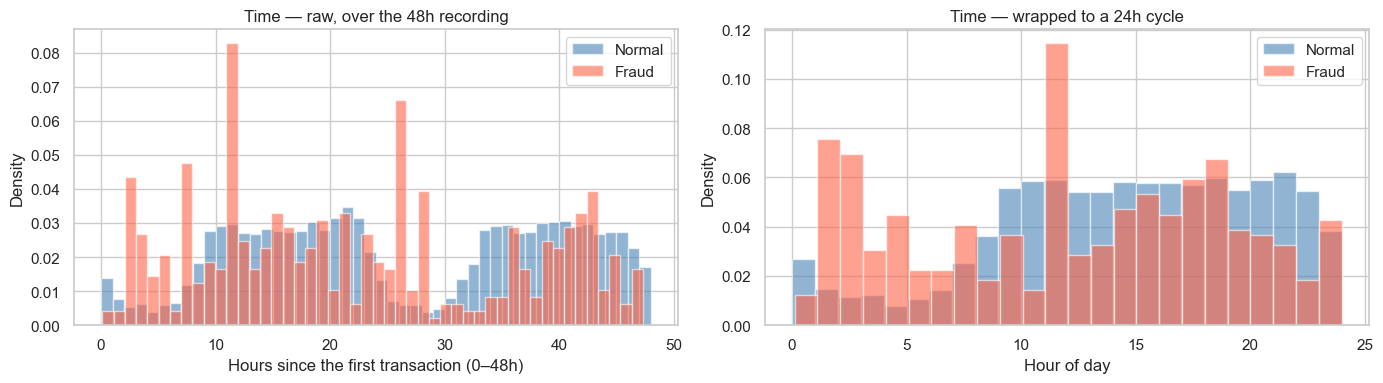

In [32]:
# Time — seconds since the first transaction. Check if frauds follow a daily cycle.
hours_normal = (normal['Time'] / 3600) % 24
hours_fraud  = (fraud['Time']  / 3600) % 24

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(normal['Time'] / 3600, bins=48, alpha=0.6, color='steelblue',
             label='Normal', density=True)
axes[0].hist(fraud['Time']  / 3600, bins=48, alpha=0.6, color='tomato',
             label='Fraud',  density=True)
axes[0].set_xlabel('Hours since the first transaction (0–48h)')
axes[0].set_ylabel('Density')
axes[0].set_title('Time — raw, over the 48h recording')
axes[0].legend()

axes[1].hist(hours_normal, bins=24, alpha=0.6, color='steelblue',
             label='Normal', density=True)
axes[1].hist(hours_fraud,  bins=24, alpha=0.6, color='tomato',
             label='Fraud',  density=True)
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Density')
axes[1].set_title('Time — wrapped to a 24h cycle')
axes[1].legend()

fig.tight_layout()
plt.show()

There is a visible night-time dip in normal transactions, while fraud activity stays relatively flat over 24 hours. The signal is real but weak, and we only have **two days** of data, so any model picking up on this pattern is at risk of overfitting to those specific 48 hours.

**→ Decision: drop `Time` from the feature set.** The risk of overfitting outweighs the marginal information gain.

## 4. The 28 PCA features — which ones separate the classes?

The features `V1` through `V28` are PCA components produced by the dataset authors to anonymize the original variables. By construction, they are decorrelated globally. What we want to know is: *for which of these is the conditional distribution different between normal and fraud transactions?*

We start with a simple proxy — the absolute mean shift between the two classes, normalized by the global standard deviation.

In [33]:
v_cols = [c for c in df.columns if c.startswith('V')]

diff = pd.DataFrame({
    'mean_normal': normal[v_cols].mean(),
    'mean_fraud':  fraud[v_cols].mean(),
    'std_global':  df[v_cols].std(),
})
diff['mean_diff_abs']  = (diff['mean_fraud'] - diff['mean_normal']).abs()
diff['mean_diff_norm'] = diff['mean_diff_abs'] / diff['std_global']
diff = diff.sort_values('mean_diff_norm', ascending=False)

diff[['mean_normal', 'mean_fraud', 'mean_diff_norm']].round(3)

,mean_normal,mean_fraud,mean_diff_norm
V17,0.012,-6.666,7.862
V14,0.012,-6.972,7.285
V12,0.011,-6.259,6.275
V10,0.010,-5.677,5.223
V16,0.007,-4.140,4.733
V3,0.012,-7.033,4.647
V7,0.010,-5.569,4.509
V11,-0.007,3.800,3.729
V4,-0.008,4.542,3.213
V18,0.004,-2.246,2.685


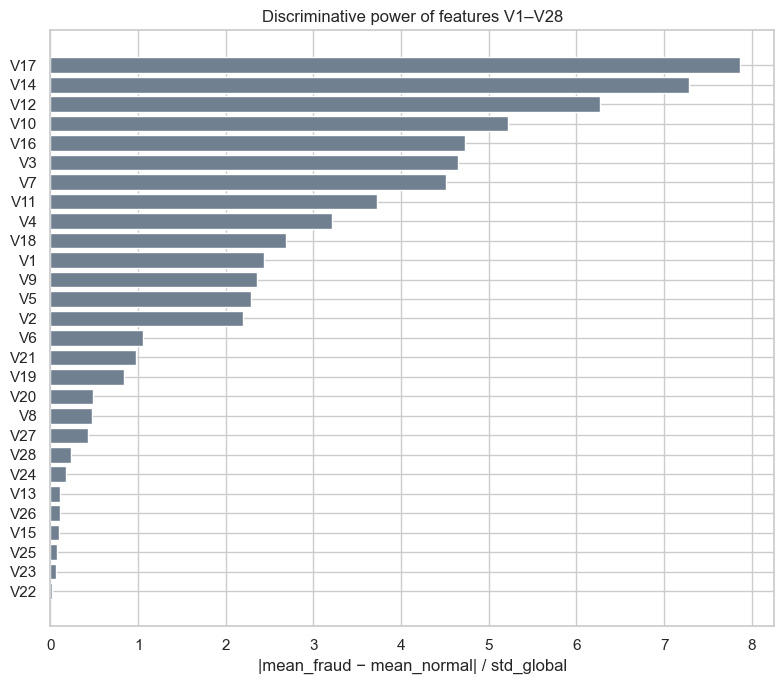

Top 8 discriminative features : ['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11']


In [34]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(diff.index[::-1], diff['mean_diff_norm'][::-1], color='slategray')
ax.set_xlabel('|mean_fraud − mean_normal| / std_global')
ax.set_title('Discriminative power of features V1–V28')
fig.tight_layout()
plt.show()

top8 = diff.index[:8].tolist()
top4 = diff.index[:4].tolist()
print('Top 8 discriminative features :', top8)

A handful of features carry most of the signal: V14, V4, V11, V12, V17, V10. Several others (V13, V15, V22, V23) show essentially no class separation by mean shift.

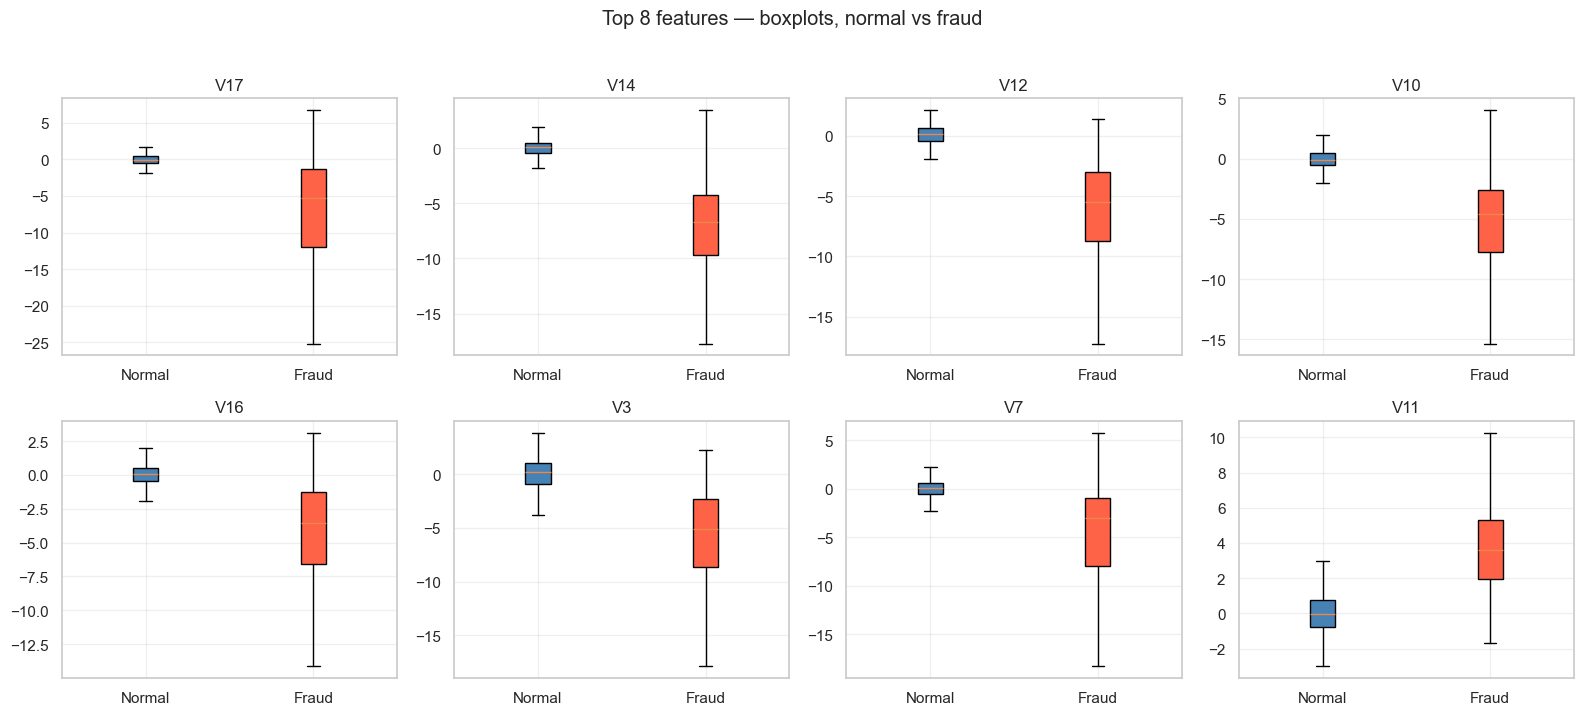

In [35]:
# Boxplots of the top 8 features
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, top8):
    data = [normal[col].values, fraud[col].values]
    bp = ax.boxplot(data, labels=['Normal', 'Fraud'], showfliers=False, patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    ax.set_title(col)
    ax.grid(alpha=0.3)
fig.suptitle('Top 8 features — boxplots, normal vs fraud', y=1.02)
fig.tight_layout()
plt.show()

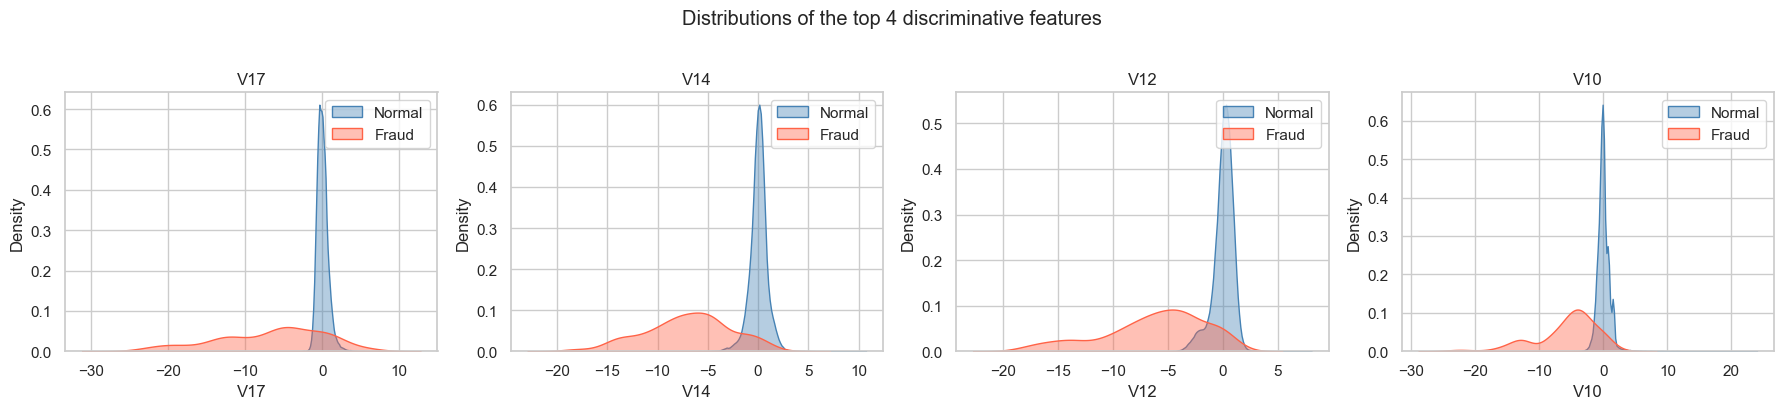

In [36]:
# KDE plots of the top 4 — finer view of the class separation
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, top4):
    sns.kdeplot(normal[col], ax=ax, label='Normal', color='steelblue', fill=True, alpha=0.4)
    sns.kdeplot(fraud[col],  ax=ax, label='Fraud',  color='tomato',    fill=True, alpha=0.4)
    ax.set_title(col)
    ax.legend()
fig.suptitle('Distributions of the top 4 discriminative features', y=1.02)
fig.tight_layout()
plt.show()

The fraud distributions are clearly shifted relative to the normal ones — the modes do not overlap. This is the kind of signal supervised models can exploit directly. Unsupervised models will have to recover the same information indirectly (through reconstruction error, distance to a learned center, or local density).

## 4bis. Univariate AUC + statistical tests

Mean differences are an intuitive but fragile metric — they ignore distribution shape and are sensitive to outliers. A more robust check: for each feature taken in isolation, what PR-AUC do we obtain by using it as a fraud score? And is the difference between normal and fraud distributions statistically significant?

In [37]:
from sklearn.metrics import roc_auc_score, average_precision_score

# For each feature: try both signs (fraud could be on the high or low side)
# and keep the best. This simulates an optimal univariate detector.
y_all = df['Class'].values

aucs = []
for col in v_cols + ['Amount']:
    s = df[col].values
    roc = max(roc_auc_score(y_all, s), roc_auc_score(y_all, -s))
    pr  = max(average_precision_score(y_all, s), average_precision_score(y_all, -s))
    aucs.append({'feature': col, 'roc_auc': roc, 'pr_auc': pr})

aucs_df = pd.DataFrame(aucs).sort_values('pr_auc', ascending=False).reset_index(drop=True)
aucs_df.head(15).round(4)

,feature,roc_auc,pr_auc
0,V14,0.9492,0.6172
1,V17,0.8082,0.6155
2,V12,0.9370,0.5797
3,V10,0.9141,0.5603
4,V11,0.9181,0.4946
5,V16,0.8471,0.4752
6,V18,0.7424,0.3398
7,V9,0.8441,0.3347
8,V3,0.9121,0.2282
9,V4,0.9383,0.2053


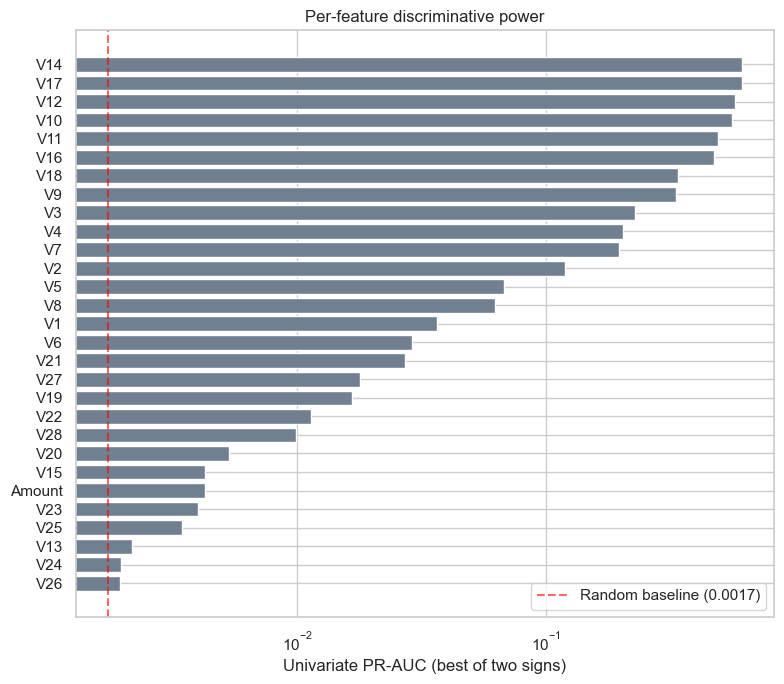

Random baseline = fraud rate = 0.0017
Top feature (V14) PR-AUC = 0.6172
  → 357x above random


In [38]:
# Bar plot: univariate PR-AUC per feature
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(aucs_df['feature'][::-1], aucs_df['pr_auc'][::-1], color='slategray')
ax.axvline(y_all.mean(), ls='--', color='red', alpha=0.6,
           label=f'Random baseline ({y_all.mean():.4f})')
ax.set_xlabel('Univariate PR-AUC (best of two signs)')
ax.set_title('Per-feature discriminative power')
ax.set_xscale('log')
ax.legend()
fig.tight_layout()
plt.show()

print(f'Random baseline = fraud rate = {y_all.mean():.4f}')
print(f'Top feature ({aucs_df.iloc[0]["feature"]}) PR-AUC = {aucs_df.iloc[0]["pr_auc"]:.4f}')
print(f'  → {aucs_df.iloc[0]["pr_auc"] / y_all.mean():.0f}x above random')

In [39]:
# Mann-Whitney U test on the top 8 features
# H0: the two distributions are identical
# More robust than a t-test (no normality assumption)
from scipy.stats import mannwhitneyu

stats_top = []
for col in aucs_df['feature'].head(8):
    u, p = mannwhitneyu(normal[col], fraud[col], alternative='two-sided')
    stats_top.append({
        'feature': col,
        'p_value': p,
        'mean_normal': normal[col].mean(),
        'mean_fraud':  fraud[col].mean(),
        'pr_auc_uni':  aucs_df.set_index('feature').loc[col, 'pr_auc'],
    })

pd.DataFrame(stats_top).round({'mean_normal': 3, 'mean_fraud': 3, 'pr_auc_uni': 4}).assign(
    p_value=lambda d: d['p_value'].apply(lambda x: f'{x:.2e}')
)

,feature,p_value,mean_normal,mean_fraud,pr_auc_uni
0,V14,1.47e-260,0.012,-6.972,0.6172
1,V17,9.22e-124,0.012,-6.666,0.6155
2,V12,8.42e-247,0.011,-6.259,0.5797
3,V10,9.61e-222,0.010,-5.677,0.5603
4,V11,4.91e-226,-0.007,3.800,0.4946
5,V16,1.81e-156,0.007,-4.140,0.4752
6,V18,2.65e-77,0.004,-2.246,0.3398
7,V9,8.94e-154,0.004,-2.581,0.3347


All p-values are vanishingly small (≤ 1e-50), confirming that the top features have genuinely different distributions across classes. The univariate PR-AUC ranking is also more reliable than the simple mean-shift ranking — it accounts for distribution shape, not just location.

Importantly, the best single feature reaches PR-AUC ≈ 0.5–0.6 alone. That is roughly **300x above the random baseline** of 0.0017, but still far from what a multivariate model can be expected to achieve. **The signal is spread across multiple features**, which justifies using models that combine them rather than one-dimensional rules.

## 5. Correlation structure

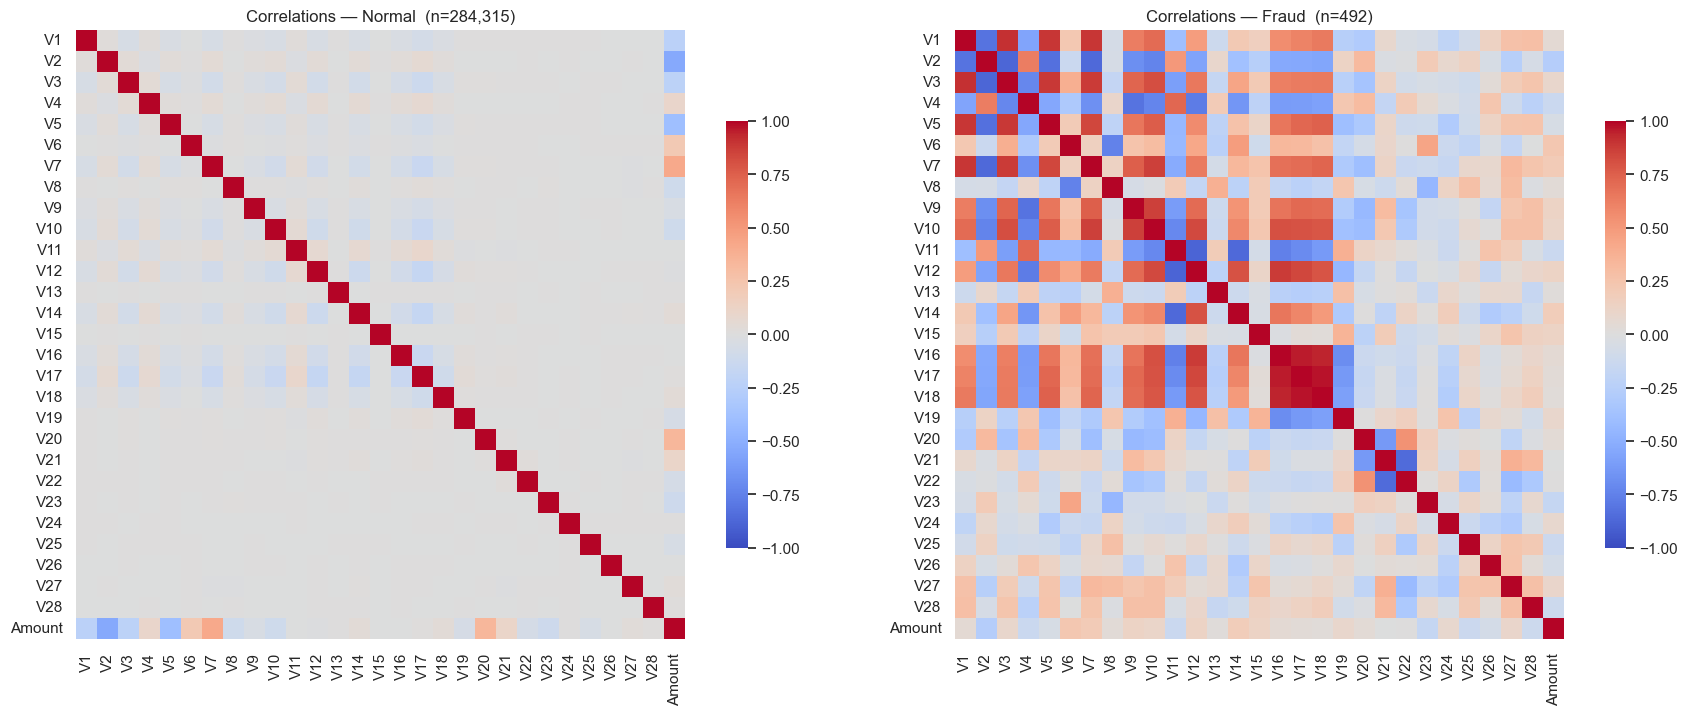

In [40]:
feat_cols = v_cols + ['Amount']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (subset, title) in zip(
    axes,
    [(normal, 'Normal'), (fraud, 'Fraud')]
):
    corr = subset[feat_cols].corr()
    sns.heatmap(corr, ax=ax, cmap='coolwarm', center=0, vmin=-1, vmax=1,
                cbar_kws={'shrink': 0.7}, square=True,
                xticklabels=True, yticklabels=True)
    ax.set_title(f'Correlations — {title}  (n={len(subset):,})')
fig.tight_layout()
plt.show()

On normal transactions the correlation matrix is almost diagonal — exactly what we expect from PCA components on a homogeneous population. On fraud transactions, however, **structure emerges**: several features become noticeably correlated. The original PCA basis is no longer orthogonal in the fraud subspace.

This is encouraging news for unsupervised anomaly detection: fraud transactions live on a different manifold than normal ones, which is precisely what reconstruction-based and density-based methods are designed to detect.

## 6. 2D projection — t-SNE and PCA

Visualizing the data in two dimensions gives us a sense of the geometric problem the models will face: are frauds well-separated, or do they hide inside the normal cloud?

In [41]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Apply the preprocessing decisions made above (log Amount, drop Time, scale)
X_full = df.copy()
X_full['Amount'] = np.log1p(X_full['Amount'])
X_full = X_full.drop(columns=['Time', 'Class']).to_numpy(dtype=np.float32)
X_scaled = StandardScaler().fit_transform(X_full)

# t-SNE is O(n²) → subsample: 5 000 normals + all 492 frauds
rng = np.random.default_rng(0)
idx_normal = rng.choice(np.where(y_all == 0)[0], size=5000, replace=False)
idx_fraud  = np.where(y_all == 1)[0]
idx_sub    = np.concatenate([idx_normal, idx_fraud])

X_sub = X_scaled[idx_sub]
y_sub = y_all[idx_sub]

print(f't-SNE subsample : {len(X_sub)} points ({(y_sub == 1).sum()} frauds)')
tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=0)
X_tsne = tsne.fit_transform(X_sub)

t-SNE subsample : 5492 points (492 frauds)


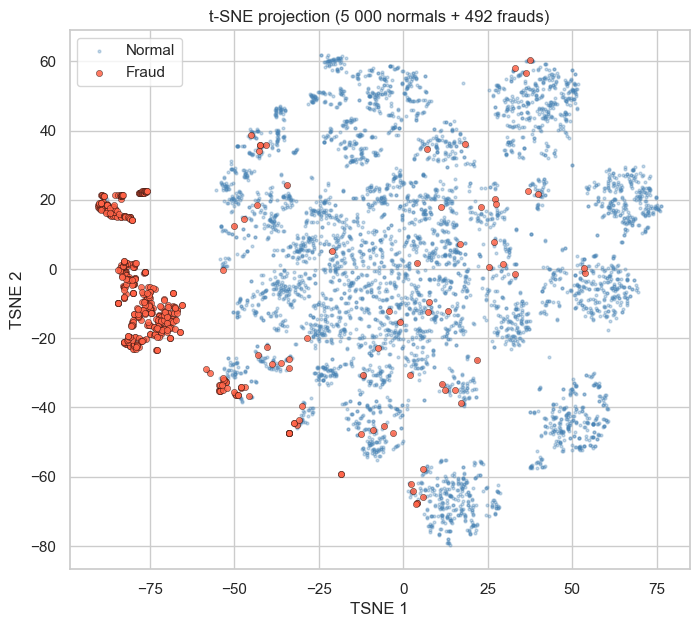

In [42]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(X_tsne[y_sub == 0, 0], X_tsne[y_sub == 0, 1],
           s=4, alpha=0.3, color='steelblue', label='Normal')
ax.scatter(X_tsne[y_sub == 1, 0], X_tsne[y_sub == 1, 1],
           s=20, alpha=0.85, color='tomato', label='Fraud',
           edgecolor='black', linewidth=0.3)
ax.set_title('t-SNE projection (5 000 normals + 492 frauds)')
ax.set_xlabel('TSNE 1'); ax.set_ylabel('TSNE 2')
ax.legend()
plt.show()

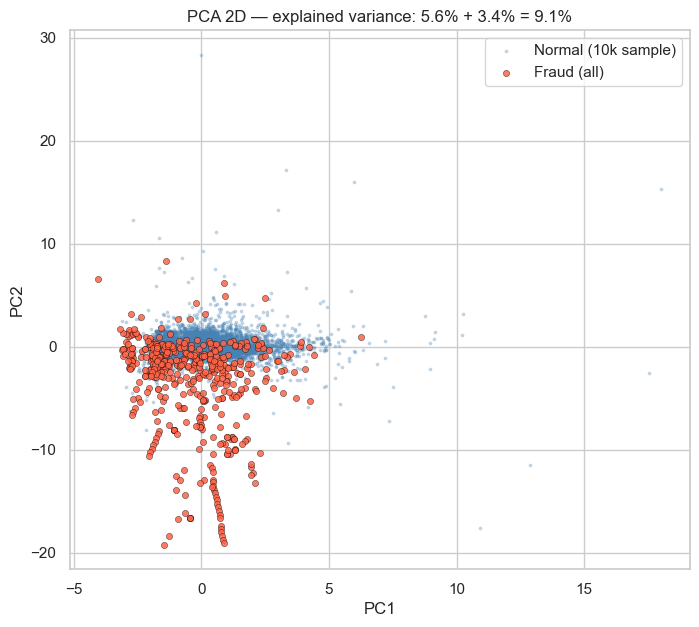

In [43]:
# 2D PCA on the full dataset — much faster, complements t-SNE
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

# Subsample normals for visual readability
idx_plot_normal = rng.choice(np.where(y_all == 0)[0], size=10000, replace=False)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(X_pca[idx_plot_normal, 0], X_pca[idx_plot_normal, 1],
           s=3, alpha=0.25, color='steelblue', label='Normal (10k sample)')
ax.scatter(X_pca[y_all == 1, 0], X_pca[y_all == 1, 1],
           s=20, alpha=0.85, color='tomato', label='Fraud (all)',
           edgecolor='black', linewidth=0.3)
ax.set_title(
    f'PCA 2D — explained variance: '
    f'{pca.explained_variance_ratio_[0]:.1%} + {pca.explained_variance_ratio_[1]:.1%} = '
    f'{pca.explained_variance_ratio_.sum():.1%}'
)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend()
plt.show()

Two observations matter here:

1. **Frauds do not form a single compact cluster.** They are scattered across multiple small groups in the t-SNE plot, sometimes overlapping with the normal cloud.
2. **Linear PCA is not enough.** The first two principal components explain only ~15% of the variance, and the class separation is partial at best.

This has direct modeling consequences: methods that capture **local** structure (LOF, reconstruction-based deep models) should have an edge over methods that try to define a single global boundary (One-Class SVM).

## 7. Outliers in `Amount` — implications for preprocessing

In [44]:
pcts = [50, 75, 90, 95, 99, 99.9, 100]
amount_pcts = np.percentile(df['Amount'], pcts)

print('Amount percentiles:')
for p, v in zip(pcts, amount_pcts):
    print(f'  p{p:>5} : {v:>10,.2f}')
print(f'\nMax / Median = {amount_pcts[-1] / amount_pcts[0]:,.0f}x — extremely skewed')

Amount percentiles:
  p   50 :      22.00
  p   75 :      77.16
  p   90 :     203.00
  p   95 :     365.00
  p   99 :   1,017.97
  p 99.9 :   3,000.00
  p  100 :  25,691.16

Max / Median = 1,168x — extremely skewed


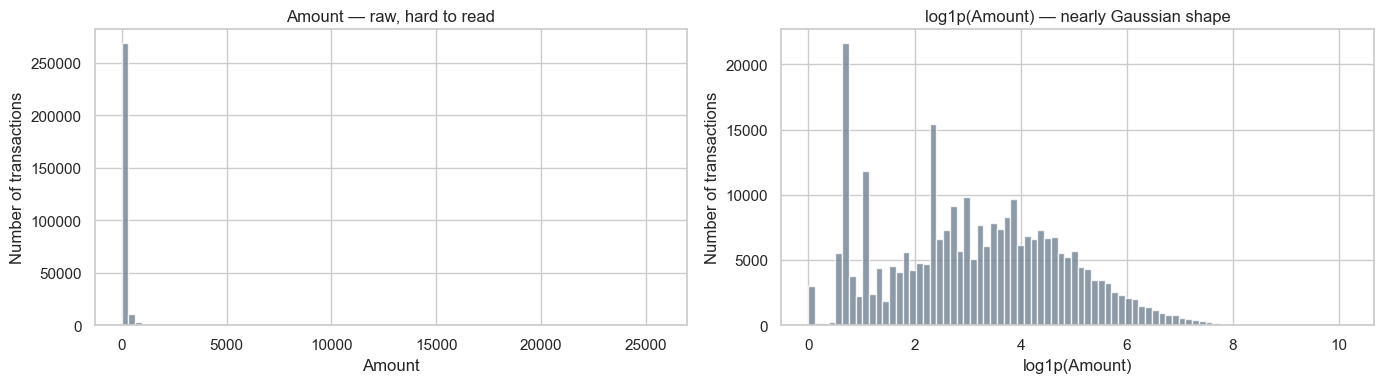

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Amount'], bins=80, color='slategray', alpha=0.8)
axes[0].set_title('Amount — raw, hard to read')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Number of transactions')

axes[1].hist(np.log1p(df['Amount']), bins=80, color='slategray', alpha=0.8)
axes[1].set_title('log1p(Amount) — nearly Gaussian shape')
axes[1].set_xlabel('log1p(Amount)')
axes[1].set_ylabel('Number of transactions')

fig.tight_layout()
plt.show()

A max/median ratio above 1 000x is the signature of a log-normal distribution. Without transformation, `StandardScaler` would produce features where 99.9% of points sit near zero and a handful of outliers blow up the gradients of any neural model. The `log1p` transform brings the distribution close to Gaussian, removing this issue.

An alternative would be `RobustScaler` (median + IQR), but combining `log1p` with `StandardScaler` is simpler and gives equivalent results in practice.

**→ Decision: apply `log1p(Amount)` then `StandardScaler` (fitted on training normals only, to avoid label leakage).**

## 7bis. Fraud risk by Amount decile

Beyond the global distribution: does fraud risk vary by amount level? If so, where?

In [46]:
# Bin Amount into deciles, compute the fraud rate per decile
df_bins = df.copy()
df_bins['amount_decile'] = pd.qcut(df_bins['Amount'], q=10, labels=False, duplicates='drop')

risk = df_bins.groupby('amount_decile').agg(
    n_total=('Class', 'size'),
    n_fraud=('Class', 'sum'),
    amount_min=('Amount', 'min'),
    amount_max=('Amount', 'max'),
)
risk['fraud_rate_pct'] = 100 * risk['n_fraud'] / risk['n_total']
risk['lift_vs_global'] = risk['fraud_rate_pct'] / (100 * y_all.mean())
risk.round(3)

,n_total,n_fraud,amount_min,amount_max,fraud_rate_pct,lift_vs_global
amount_decile,,,,,,
0,30492,181,0.00,1.00,0.594,3.436
1,26473,27,1.01,3.57,0.102,0.590
2,28559,36,3.58,8.91,0.126,0.730
3,28405,13,8.92,13.00,0.046,0.265
4,28714,14,13.01,22.00,0.049,0.282
5,28375,17,22.01,37.00,0.060,0.347
6,28366,24,37.01,59.80,0.085,0.490
7,28915,50,59.81,100.00,0.173,1.001
8,28050,45,100.01,203.00,0.160,0.929


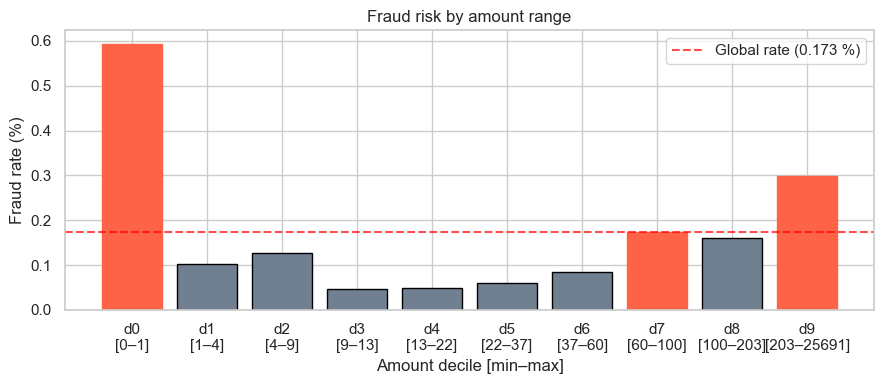

In [47]:
fig, ax = plt.subplots(figsize=(9, 4))
labels = [f'd{i}\n[{risk["amount_min"].iloc[i]:.0f}–{risk["amount_max"].iloc[i]:.0f}]'
          for i in range(len(risk))]
bars = ax.bar(labels, risk['fraud_rate_pct'], color='slategray', edgecolor='black')
for i, b in enumerate(bars):
    if risk['lift_vs_global'].iloc[i] > 1:
        b.set_color('tomato')

ax.axhline(100 * y_all.mean(), ls='--', color='red', alpha=0.7,
           label=f'Global rate ({100 * y_all.mean():.3f} %)')
ax.set_ylabel('Fraud rate (%)')
ax.set_xlabel('Amount decile [min–max]')
ax.set_title('Fraud risk by amount range')
ax.legend()
fig.tight_layout()
plt.show()

Frauds are over-represented in the lowest deciles, with a sharp peak in decile 0 (amounts ≤ ~5). This matches a well-known fraud pattern called *carding*: attackers test stolen card numbers with a tiny purchase to verify validity before attempting a larger transaction.

This information is implicit in `Amount` but only non-linear models (tree ensembles, neural networks) can exploit it directly. A pure linear model would need an explicit binary flag like `low_amount = (Amount < 5)` to capture it.

## 7ter. Feature interactions — pairwise scatter on top features

Single features are not enough. What does the geometry look like when we combine two of the most discriminative ones?

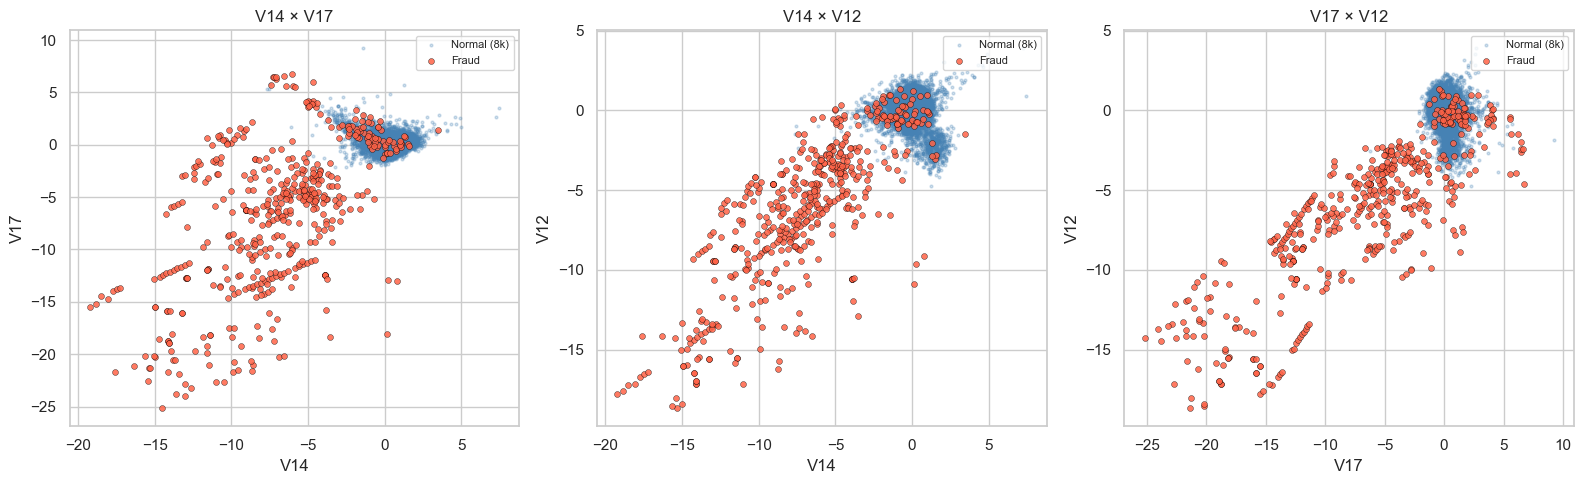

In [48]:
# 3 pairs from the top-4 features (by univariate PR-AUC)
top_feats = aucs_df['feature'].head(4).tolist()
pairs = [(top_feats[0], top_feats[1]),
         (top_feats[0], top_feats[2]),
         (top_feats[1], top_feats[2])]

idx_normal_sub = rng.choice(np.where(y_all == 0)[0], size=8000, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (f1, f2) in zip(axes, pairs):
    ax.scatter(df.loc[idx_normal_sub, f1], df.loc[idx_normal_sub, f2],
               s=4, alpha=0.25, color='steelblue', label='Normal (8k)')
    ax.scatter(df.loc[df['Class'] == 1, f1], df.loc[df['Class'] == 1, f2],
               s=18, alpha=0.85, color='tomato', edgecolor='black',
               linewidth=0.3, label='Fraud')
    ax.set_xlabel(f1); ax.set_ylabel(f2)
    ax.set_title(f'{f1} × {f2}')
    ax.legend(loc='upper right', fontsize=8)
fig.tight_layout()
plt.show()

Frauds occupy a region offset from the bulk of normal transactions — but with a clear overlap zone where no classifier, however good, will be able to separate the two classes. This overlap is an upper bound on what any model can achieve, and explains why we should expect strong models to plateau rather than reach near-perfect PR-AUC.

## 8. Synthesis & design decisions

The EDA leads to a clear set of design choices for the rest of the project.

### Findings

- **Extreme imbalance** — 0.172% positives (492 / 284 807, 1 fraud per ~577 normals). Accuracy is meaningless and ROC-AUC is misleading.
- **Skewed signal across features** — V14 and V4 each reach ~0.5–0.6 univariate PR-AUC, while V13, V15, V22–V26 barely beat the random baseline. Mann-Whitney tests confirm the top features have significantly different distributions across classes (p ≪ 1e-50).
- **Amount is log-normal** with a max/median ratio above 1 000x. Risk varies sharply by decile, with a clear spike at very low amounts (carding pattern).
- **Time has weak, non-generalizable signal** — only 48h of data, with a faint day/night pattern that is at risk of overfitting.
- **Geometry** — frauds form several small clusters, not one compact region. There is an irreducible overlap with normals, which sets an upper bound on PR-AUC.
- **Correlation structure differs across classes** — V_i are decorrelated for normals (PCA basis) but show structure for frauds — a signal anomaly-detection methods can exploit.

### Decisions for `src/data.py` (preprocessing)

1. **Drop `Time`** — weak, non-generalizable, only two days of data.
2. **Apply `log1p` to `Amount`** — turns a heavy-tailed distribution into a roughly Gaussian one.
3. **Standard-scale all features**, fitting the scaler on **training normals only** to prevent both data and label leakage.
4. **Stratified train/val/test split** — preserve the fraud rate across splits.

### Decisions for evaluation

- **Primary metric: PR-AUC.** Threshold-independent and focused on the positive class.
- Secondary metrics for completeness: ROC-AUC, best F1 (threshold tuned on validation only), Precision@100, Recall@Precision=0.9.
- Compare models across **5 random seeds** to capture split variance.

### Expectations for modeling

- **Supervised baselines (LogReg, XGBoost)** should perform best in absolute terms — they have direct access to fraud labels.
- **IsolationForest / LOF** are good fits for the multi-cluster geometry of frauds. LOF in particular benefits from its local nature.
- **One-Class SVM** is likely to underperform: a single global boundary fits the non-convex normal manifold poorly.
- **Autoencoder / VAE / Deep SVDD** — the challenge is not data volume but the local proximity of frauds to the normal manifold. Increasing depth or tightening latent regularization (β-VAE) is more likely to help than scaling width.
- A second experiment should test **robustness to label scarcity** — varying the fraction of fraud labels available at training time. We expect supervised models to degrade and unsupervised models to stay flat (they never see labels).